# DAY 2

## InsightFace Detection

In [2]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
print("os done")
import numpy as np
import glob
import cv2
import matplotlib.pyplot as plt
print("start")
import insightface
print("insightface ok")
from insightface.app import FaceAnalysis
print("FaceAnalysis ok")
from insightface.data import get_image as ins_get_image
print('aaaa')

os done
start
insightface ok
FaceAnalysis ok
aaaa


In [3]:
print('insightface', insightface.__version__)
print('np', np.__version__)

# Detect Faces

app = FaceAnalysis(name='buffalo_l')
app.prepare(ctx_id=0, det_size=(640, 640))

insightface 0.7.3
np 1.26.4
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}

c:\Users\jaema\anaconda3\Lib\site-packages\onnxruntime\capi\onnxruntime_inference_collection.py:123: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(



find model: C:\Users\jaema/.insightface\models\buffalo_l\1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\jaema/.insightface\models\buffalo_l\2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\jaema/.insightface\models\buffalo_l\det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\jaema/.insightface\models\buffalo_l\genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\jaema/.insightface\models\buffalo_l\w600k_r50.onnx recognition ['None', 3, 112, 112] 127.5 127.5
set det-size: (640, 640)


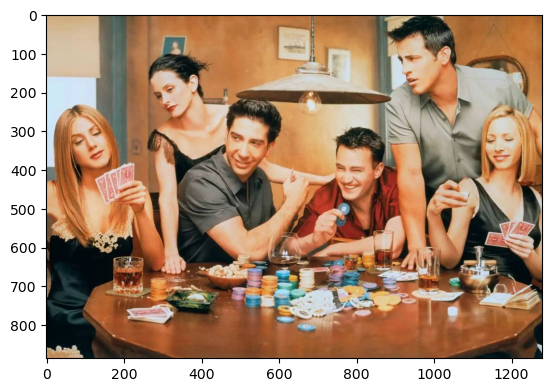

In [4]:
img = ins_get_image('t1')
plt.imshow(img[:,:,::-1])
plt.show()

In [5]:
faces = app.get(img)

c:\Users\jaema\anaconda3\Lib\site-packages\insightface\utils\transform.py:68: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  P = np.linalg.lstsq(X_homo, Y)[0].T # Affine matrix. 3 x 4


In [6]:
faces[0].keys()

dict_keys(['bbox', 'kps', 'det_score', 'landmark_3d_68', 'pose', 'landmark_2d_106', 'gender', 'age', 'embedding'])

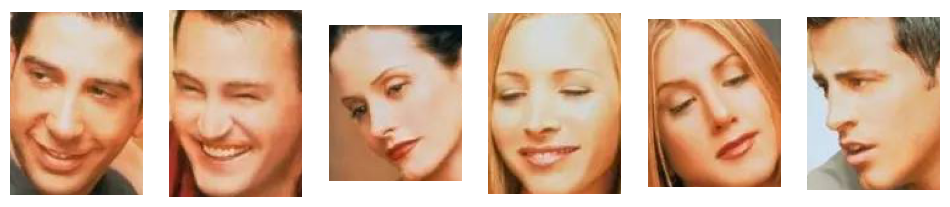

In [7]:
# 1 - Crop & plot faces

img = ins_get_image('t1')
fig, axs = plt.subplots(1,6, figsize=(12, 5))

for i, face in enumerate(faces):
    bbox = face['bbox']
    bbox = [int(b) for b in bbox]
    axs[i].imshow(img[bbox[1]:bbox[3], bbox[0]:bbox[2],::-1])
    axs[i].axis('off')

In [8]:
# 2 - face swapping
# Weight -> https://huggingface.co/ezioruan/inswapper_128.onnx/tree/main 
swapper = insightface.model_zoo.get_model('inswapper_128.onnx', download=False, download_zip=False)

Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
inswapper-shape: [1, 3, 128, 128]


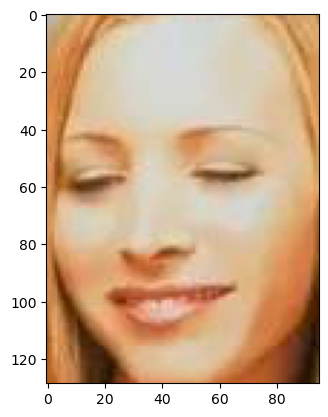

In [22]:
source_face = faces[3]
bbox = source_face['bbox']
bbox = [int(b) for b in bbox]
plt.imshow(img[bbox[1]:bbox[3], bbox[0]:bbox[2],::-1])
plt.show()

In [23]:
img_copy = img.copy()

for face in faces:
    img_copy = swapper.get(img_copy, face, source_face, paste_back=True)

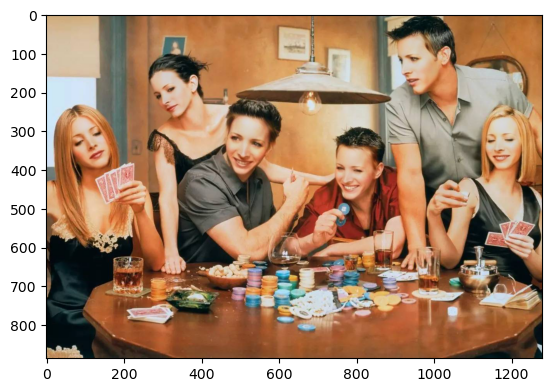

In [24]:
# 3 - After 'swapper.get'
plt.imshow(img_copy[:,:,::-1])
plt.show()

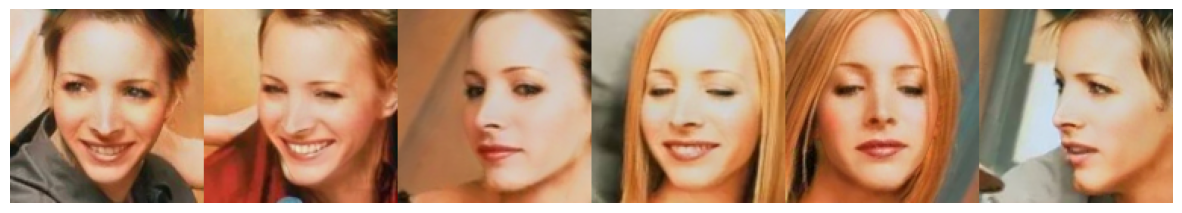

In [25]:
result = []
for face in faces:
    _img, _ = swapper.get(img, face, source_face, paste_back=False)
    result.append(_img)
result = np.concatenate(result, axis=1)
fig, ax = plt.subplots(figsize=(15, 5))
ax.imshow(result[:,:,::-1])
ax.axis('off')
plt.show()

In [ ]:
# Detect Faces using InsightFace
def draw_fps(frame, fps):
    cv2.putText(
        frame, # img
        f"FPS: {int(fps)}", # text
        (10, 30), # org
        cv2.FONT_HERSHEY_SIMPLEX, # fontFace
        1, # fontScale
        (255, 0, 0), # color, BGR
        2 # thickness
    )


app = FaceAnalysis(name='buffalo_s', allowed_modules=['detection']) # buffalo_sc
# default det_size=(640, 640))
app.prepare(ctx_id=-1, det_size=(256, 256))

cap = cv2.VideoCapture(0)

scale = 0.5

while True:
    ret, frame = cap.read()
    if not ret:
        break

    small_frame = cv2.resize(frame, (0, 0), fx=0.5, fy=0.5)

    faces = app.get(small_frame)

    for face in faces:
        x1, y1, x2, y2 = map(int, face.bbox)

        x1 = int(x1 / scale)
        y1 = int(y1 / scale)
        x2 = int(x2 / scale)
        y2 = int(y2 / scale)

        cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
    
    cv2.imshow("Face Detection", frame)

    key = cv2.waitKey(1)
    
    if key == ord('q') or key == ord('й'):
        break

cap.release()
cv2.destroyAllWindows()

# Day 3
